## Импорт библиотек

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

## Загрузка данных

Этот датасет — LIMFADD (LLM-enabled Instagram Multi-Class Fake Account Detection Dataset) — создан для многоуровневой классификации аккаунтов в Instagram и представляет собой улучшение по сравнению с бинарными датасетами, которые делят пользователей только на "настоящих" и "фейковых". LIMFADD включает реальные данные и сгенерированные с помощью LLM (например, ChatGPT), что позволило расширить объем выборки и сохранить достоверность поведенческих признаков.

В отличие от предыдущих подходов, LIMFADD позволяет различать типы фейковых аккаунтов, что даёт более глубокое понимание моделей их поведения. В выборке представлены четыре класса Labels:

Real — настоящие аккаунты реальных пользователей с естественными поведенческими характеристиками;

Spam — аккаунты, распространяющие однотипные сообщения или ссылки в комментариях;

Scam — мошеннические аккаунты, использующие фишинговые ссылки и обманные схемы;

Bot — автоматизированные аккаунты, активно взаимодействующие (лайки, подписки) с ненормальной частотой.

In [2]:
df = pd.read_csv('LIMFADD.csv')
df.head()

,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,N,N,N,0,N,Bot
1,2,505,252.5,0,0,N,Yes,N,0,N,Scam
2,6786,1782,0.262599469,1589,6051.040404,yes,N,Yes,10,N,Real
3,21,1281,61,0,0,N,Yes,N,0,N,Bot
4,585,1682,2.875213675,2663,926.1920333,yes,N,N,12,Yes,Real


## Преобразование целевого признака

Преобразование бинарных категориальных признаков на 0/1, а также преобразование меток классов с Bot/Real/Scam/Spam на 0/1/2/3.

In [4]:
binary_cols = ['Bio', 'Profile Picture', 'External Link', 'Threads']
df[binary_cols] = df[binary_cols].map(lambda x: 1 if str(x).strip().lower() in ['yes', 'y'] else 0)
le = LabelEncoder()
df['Labels'] = le.fit_transform(df['Labels'])
df.head()

,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,0,0,0,0,0,0
1,2,505,252.5,0,0,0,1,0,0,0,2
2,6786,1782,0.262599469,1589,6051.040404,1,0,1,10,0,1
3,21,1281,61,0,0,0,1,0,0,0,0
4,585,1682,2.875213675,2663,926.1920333,1,0,0,12,1,1


## Разделение данных на признаки и целевую переменную

X — это набор признаков (features), который будет использоваться для предсказания целевой переменной. Выбираются столбцы из DataFrame (df), которые представляют важные параметры.

y — это целевая переменная, которая представляет, 4 категории аккаунтов.

А также необходимо очистить данные от некорректных значений.

In [5]:
x = df.drop('Labels', axis=1)
y = df['Labels']

x.replace('#DIV/0!', np.nan, inplace=True)
x = x.apply(pd.to_numeric, errors='coerce')
x.dropna(inplace=True)
y = y[x.index]

print('Содержание набора признаков')
print(x[:5])
print('Целевая переменная')
print(y[:5])

Содержание набора признаков
   Followers  Following  Following/Followers  Posts  Posts/Followers  Bio  \
0          2       2757          1378.500000      0         0.000000    0   
1          2        505           252.500000      0         0.000000    0   
2       6786       1782             0.262599   1589      6051.040404    1   
3         21       1281            61.000000      0         0.000000    0   
4        585       1682             2.875214   2663       926.192033    1   

   Profile Picture  External Link  Mutual Friends  Threads  
0                0              0               0        0  
1                1              0               0        0  
2                0              1              10        0  
3                1              0               0        0  
4                0              0              12        1  
Целевая переменная
0    0
1    2
2    1
3    0
4    1
Name: Labels, dtype: int64


## Разделение на обучающую и тестовую выборки

Из всей выборки 20% случайным образом определяются в качестве тестовой выборки, 80% же являются обучающей выборкой.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Содержание обучающего набора признаков')
print(x_train[:5])
print('Целевая переменная обучающего набора')
print(y_train[:5])
print('Содержание тестового набора признаков')
print(x_test[:5])
print('Целевая переменная тестового набора')
print(y_test[:5])

Содержание обучающего набора признаков
       Followers  Following  Following/Followers  Posts  Posts/Followers  Bio  \
3818           4        228            57.000000      1         0.017544    1   
2319           1          3             3.000000      4         1.333333    1   
8755      144693        804             0.005557    129     23215.667910    0   
11895          1        730           730.000000      2         0.002740    1   
4128       13529        588             0.043462    712     16382.054420    0   

       Profile Picture  External Link  Mutual Friends  Threads  
3818                 1              0               0        0  
2319                 1              0               0        0  
8755                 1              1               9        0  
11895                1              0               0        0  
4128                 0              0               1        1  
Целевая переменная обучающего набора
3818     2
2319     2
8755     3
11895    2
412

## Масштабирование признаков


In [7]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
print('Масштабированный обучающий набор признаков')
print(x_train[:5])
print('Масштабированный тестовый набор признаков')
print(x_test[:5])

Масштабированный обучающий набор признаков
[[-0.57200522 -0.73047266 -0.1606416  -0.64406065 -0.10046739  1.16346405
   1.01369031 -0.59632198 -0.73699527 -0.59525452]
 [-0.572076   -0.86978373 -0.31913397 -0.63968808 -0.10046542  1.16346405
   1.01369031 -0.59632198 -0.73699527 -0.59525452]
 [ 2.84211187 -0.37383632 -0.3279228  -0.45749772 -0.06565532 -0.85950228
   1.01369031  1.6769464   1.3853379  -0.59525452]
 [-0.572076   -0.41965418  1.81464301 -0.64260312 -0.10046741  1.16346405
   1.01369031 -0.59632198 -0.73699527 -0.59525452]
 [-0.252866   -0.50757495 -0.32781154  0.39223813 -0.07590238 -0.85950228
  -0.98649458 -0.59632198 -0.50118047  1.67995366]]
Масштабированный тестовый набор признаков
[[ 1.53181239 -0.26424494 -0.32790681  0.14883181 -0.02618926  1.16346405
  -0.98649458  1.6769464   0.44207871  1.67995366]
 [ 0.13944517 -0.4598996  -0.32787438  0.20859025 -0.06062146 -0.85950228
  -0.98649458  1.6769464   0.9137083  -0.59525452]
 [ 1.64715083 -0.62707289 -0.32792678  

## Модель Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9688257706962244
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       756
           1       0.97      0.94      0.95       761
           2       0.98      1.00      0.99       625
           3       0.94      0.97      0.95       745

    accuracy                           0.97      2887
   macro avg       0.97      0.97      0.97      2887
weighted avg       0.97      0.97      0.97      2887



## Модель Support Vector Machine (SVM)

In [12]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9549705576723242
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       756
           1       0.95      0.94      0.94       761
           2       0.93      1.00      0.97       625
           3       0.94      0.95      0.94       745

    accuracy                           0.95      2887
   macro avg       0.95      0.96      0.96      2887
weighted avg       0.96      0.95      0.95      2887



## Модель K-Nearest Neighbors (KNN)

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9625909248354694
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       756
           1       0.96      0.93      0.94       761
           2       0.97      1.00      0.99       625
           3       0.93      0.95      0.94       745

    accuracy                           0.96      2887
   macro avg       0.96      0.96      0.96      2887
weighted avg       0.96      0.96      0.96      2887



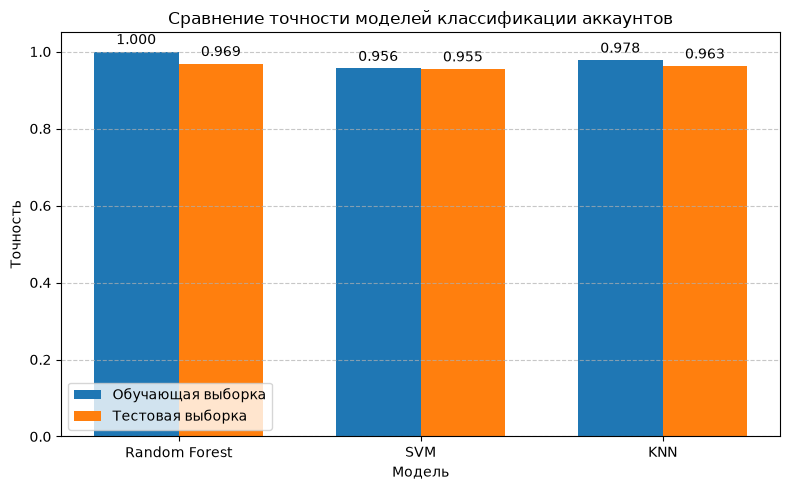

In [16]:
models = ['Random Forest', 'SVM', 'KNN']

train_acc = [rf.score(x_train, y_train), svm.score(x_train, y_train), knn.score(x_train, y_train)]

test_acc = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn)
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_acc, width, label='Обучающая выборка')
rects2 = ax.bar(x + width/2, test_acc, width, label='Тестовая выборка')

ax.set_ylabel('Точность')
ax.set_xlabel('Модель')
ax.set_title('Сравнение точности моделей классификации аккаунтов')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
